# Connaissance et pratique de la Science Ouverte

In [29]:
import pandas as pd

import os #pour naviguer dans les dossiers
from io import StringIO
import s3fs #pour connecter au bucket
import scipy.stats

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:


# Create filesystem object
S3_ENDPOINT_URL = "https://" + os.environ["AWS_S3_ENDPOINT"]
fs = s3fs.S3FileSystem(client_kwargs={'endpoint_url': S3_ENDPOINT_URL})

BUCKET_OUT = "aluneau"



In [5]:
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-07-24.csv", "r") as file_in:
    df0 = pd.read_csv(file_in, sep =",")

list_affil = pd.read_csv("../list_affiliation.csv", sep =",")
df0 = df0.loc[~df0.q45_clé.isin(["9EAP-NB4B","QNYZ-3MH2"])].merge(list_affil, on = ["q45_clé", "q44_ufr_labo"], how = "left")

In [6]:

df_col = pd.read_csv("../../le_questionnaire/dico_variable.csv", sep = ",")


In [7]:
list_nominal_simple = [x for x in df_col.label.loc[(df_col.type.isin(["simple_nominal", "booléen","ordinal"]))]]


In [8]:
def split_multiple_choices(data, column, index, sep = '|'):
    """
    split and explode column with multiple value

    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_split = data.copy()
    df_split[column]= df_split.apply(lambda row: row[column].replace(";",sep) ,1 )
    df_split[column] = df_split[column].str.split(sep)
    df_explode = df_split.explode(column)
    gb_data = df_explode.groupby([column]).agg(nb = (index, "size")).sort_values("nb", ascending=False).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100
    
    return df_explode, gb_data
    

In [9]:
def grouped_question(data, column, index = "q45_clé"):
    """


    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_tmp = data.copy()
    gb_data = df_tmp.groupby([column]).agg(nb = (index, "size")).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100

    return gb_data

In [10]:
df0

,Unnamed: 0,qno_obs,q1_so_principles,q2_hal_depot,q3_octavi_depot,q4_diff_data,q4_autres_entrepots,q5_r,q5_python,q5_excel,...,q16_network_analysis_help,q16_odette_atom_help,q16_caqdas_help,q16_carto_help,q16_sig_help,q16_sgbd_help,q16_autre_help,q16_1_other_software_help,q26_1_autre_rec,q35_ia_tools_rec
0,0,1,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,...,Non,Non,Non,Non,Non,"Oui, avancé",Non,NaN,NaN,NaN
1,1,2,"Oui, un peu","Oui, une fois",Non,Non,NaN,Non,Non,Non,...,Non,Non,Non,Non,Non,Non,Non,NaN,NaN,NaN
2,2,3,"Oui, tout à fait","Oui, plusieurs fois",Je ne connais pas Octaviana,Non,NaN,Non,Non,Oui,...,Non,Non,"Oui, débutant",Non,Non,Non,"Oui, débutant",Logiciel de traitement d'entretiens et de vidéos,NaN,chatgpt|mistral|notebooklm
3,3,4,"Oui, un peu","Oui, une fois",Non,"Autre, précisez",OSF,Oui,Non,Non,...,Non,Non,Non,Non,Non,Non,Non,NaN,NaN,chatgpt|euria
4,4,6,"Oui, un peu","Oui, systématiquement",Non;Je ne connais pas Octaviana,Non,NaN,Oui,Non,Oui,...,Non,Non,Non,Non,Non,Non,Non,NaN,NaN,chatgpt|perplexity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,114,117,"Oui, un peu","Oui, plusieurs fois",Non,"Autre, précisez",OSF,Oui,Oui,Oui,...,Non,"Oui, débutant","Oui, débutant","Oui, débutant",Non,"Oui, débutant",Non,NaN,NaN,NaN
115,115,118,"Oui, un peu","Oui, systématiquement",Non,Non,NaN,Oui,Non,Oui,...,"Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant",Non,NaN,Bibliothèque|Où je peux,claude|chatgpt
116,116,119,"Oui, un peu","Oui, plusieurs fois",Non,Non,NaN,Oui,Non,Oui,...,"Oui, débutant",Non,Non,Non,"Oui, avancé","Oui, débutant",Non,NaN,NaN,NaN
117,117,120,Non,"Oui, plusieurs fois",Non;Je ne connais pas Octaviana,"Autre, précisez",Mendeley data,Non,Oui,Oui,...,"Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant","Oui, avancé","Oui, débutant",​-,NaN,correcteurs d'orthographe


In [11]:
df_col["question_family"] = df_col.label.apply(lambda row : row.split("_")[0])

dict_question = dict(zip(df_col.label.loc[df_col.label.isin(list_nominal_simple)], df_col.question_family.loc[df_col.label.isin(list_nominal_simple)]))


Les premières questions interrogeaient les participants sur leurs connaissances et leurs pratiques de la Science Ouverte, thème central de l'enquête. Le questionnaire commencait ainsi par demander aux participants de préciser leur degré de familiarité avec les principes de la Science Ouverte ({numref}`principe_so`}). 56% ont répond "oui, un peu", 32 "oui, tout à fait" et 12% "non". Les pratiques étaient ensuite abordaient à travers des questions sur le dépôt des publications sur Hal et Octaviana ({numref}`depot_hal` et {numref}`depot_octaviana`), et l'ouverture de données de recherche ({numref}`opened_data`).

40 % des personnes interrogées ont déposé plusieurs fois leurs publications sur Hal et 35% le font systématiquement. 13%  ne l'ont jamais fais. Concernant Octaviana, un peu moins de 10% des répondants ont déjà déposé des productions sur la bibliothèque numérique. Ces productions sont des captations d'événements pour trois d'entre elles et des travaux universitaires et des publications pour les huit autres. En tout une personne interrogée sur cinq n'a jamais entendu parlé d'Octaviana.


```{table} Connaissance des principes de la Science Ouverte
:name: principe_so
| Principes de la science ouverte   |   nb |    freq |
|:-------------------|-----:|--------:|
| Non                |   14 | 11,8 |
| Oui, tout à fait   |   38 | 31,9 |
| Oui, un peu        |   67 | 56,3 |
|Total               |119   | 100,0|
```


```{table} Le dépôt dans HAL
:name: depot_hal

|Dépôt dans Hal        |   nb |    freq |
|:----------------------|-----:|--------:|
| Non                   |   15 | 12,6  |
| Oui, plusieurs fois   |   48 | 40,3 |
| Oui, systématiquement |   41 | 34,5 |
| Oui, une fois         |   15 | 12,6 |
|Total               |119   | 100,0|
```
```{table} Le dépôt dans Octaviana
:name: depot_octaviana

| Dépot sur Octaviana  |   nb |    freq |
|:----------------|-----:|--------:|
| Non             |  108 | 90,8 |
| Oui             |   11 |  9,2|
|Total               |119   | 100,0|
```
```{table} Ouverture des données
:name: opened_data

| Ouverture des données   |   nb |   total |      freq |  
|:------------------------|-----:|--------:|----------:|
| Non                     |   86 |     119 | 72,3  |      
| Autre, précisez         |   24 |     119 | 20,7   |          
| Oui, sur Nakala         |    5 |     119 |  4,2  |          
| Oui, sur Zenodo         |    4 |     119 |  3,4  |         
| Oui, sur Data Paris 8   |    1 |     119 |  0,8 |        
```


Enfin, 28% des personnes interrogées ont déjà produit des données ouvertes. 8% d'entre elles ont utilisé au moins une fois des entrepôts généralistes comme Nakala (N=5), Zenodo (N=4) ou Data Paris 8 (N=1). Les autres modalité d'ouverture des données ({numref}`autre_entrepot_fig`) sont Open Science Framework (N=10), des sites web personnels (N=6), des dépôts "git" (N=3) et des entrepots spécialisés (N=3) liés à la linguistiques : Ortolang et Cocoon.

```{figure} ./viz/autre_entrepot_rec.png
:name: autre_entrepot_fig

Les modes d'ouverture des données
```


In [16]:
so_principe = grouped_question(df0, column="q1_so_principles", index = "q45_clé")
print(so_principe[["q1_so_principles", "nb","freq"]].to_markdown(index=False))
depot_hal = grouped_question(df0, column="q2_hal_depot", index = "q45_clé")
print("\n### Dépôt dans hal\n", depot_hal[["q2_hal_depot", "nb","freq"]].to_markdown(index=False))
octaviana = grouped_question(df0, column="q3_octavi_rec", index = "q45_clé")
print("\n### Dépôt dans Octaviana\n", octaviana[["q3_octavi_rec", "nb","freq"]].to_markdown(index=False))

df_exp, octaviana2 = split_multiple_choices(df0, column="q3_octavi_depot", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", octaviana2.to_markdown())



| q1_so_principles   |   nb |    freq |
|:-------------------|-----:|--------:|
| Non                |   14 | 11.7647 |
| Oui, tout à fait   |   38 | 31.9328 |
| Oui, un peu        |   67 | 56.3025 |

### Dépôt dans hal
 | q2_hal_depot          |   nb |    freq |
|:----------------------|-----:|--------:|
| Non                   |   15 | 12.605  |
| Oui, plusieurs fois   |   48 | 40.3361 |
| Oui, systématiquement |   41 | 34.4538 |
| Oui, une fois         |   15 | 12.605  |

### Dépôt dans Octaviana
 | q3_octavi_rec   |   nb |    freq |
|:----------------|-----:|--------:|
| Non             |  108 | 90.7563 |
| Oui             |   11 |  9.2437 |

### Dépôt dans Octaviana détaillé 
 |    | q3_octavi_depot                                         |   nb |   total |     freq |   total_freq |
|---:|:--------------------------------------------------------|-----:|--------:|---------:|-------------:|
|  0 | Non                                                     |   93 |     119 | 78.1513  | 

In [17]:
df0.loc[df0.q4_diff_data !="Non", "q4_diff_data_grouped"] = "Oui"
df0.loc[df0.q4_diff_data =="Non", "q4_diff_data_grouped"] = "Non"

depot_donnee = grouped_question(df0, column="q4_diff_data_grouped", index = "q45_clé")
print("\n### Dépôt des données de recherche\n", depot_donnee)

df_exp, depot_donnee2 = split_multiple_choices(df0, column="q4_diff_data", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", depot_donnee2.to_markdown(index=False))


### Dépôt des données de recherche
   q4_diff_data_grouped  nb  total       freq  total_freq
0                  Non  85    119  71.428571       100.0
1                  Oui  34    119  28.571429       100.0

### Dépôt dans Octaviana détaillé 
 | q4_diff_data            |   nb |   total |      freq |   total_freq |
|:------------------------|-----:|--------:|----------:|-------------:|
| Non                     |   86 |     119 | 72.2689   |          100 |
| Autre, précisez         |   24 |     119 | 20.1681   |          100 |
| Oui, sur Nakala         |    5 |     119 |  4.20168  |          100 |
| Oui, sur Zenodo, Nakala |    4 |     119 |  3.36134  |          100 |
| Oui, sur Data Paris 8   |    1 |     119 |  0.840336 |          100 |


## Les autres modes de dépôt des données de recherche

In [18]:
df0.loc[df0["q4_diff_data"]=='Autre, précisez', "q4_diff_data_rec"] = df0.q4_autres_entrepots_rec
df0.loc[df0["q4_diff_data"]!='Autre, précisez', "q4_diff_data_rec"] = df0.q4_diff_data
df0.loc[df0["q4_diff_data_rec"].isna(), "q4_diff_data_rec"] = "NSP"
q4 = split_multiple_choices(df0, column="q4_diff_data_rec", index="q45_clé", sep = '|')

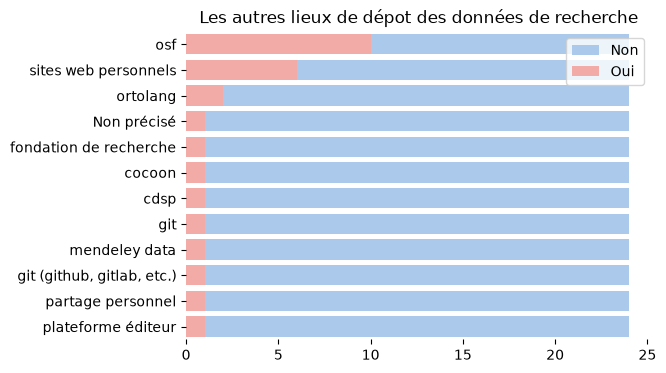

In [19]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")
q4_other = df0.loc[df0.q4_diff_data=="Autre, précisez"].fillna("Non précisé")
col= "q4_autres_entrepots_rec"
df_exp, gb_data = split_multiple_choices(q4_other, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les autres lieux de dépot des données de recherche"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"viz/autre_entrepot_rec.png", bbox_inches='tight', dpi = 200)



## Les besoins d'accompagnement à la Science Ouverte

Mis à part l'accompagnement au dépot dans Hal considéré comme inutile par 68% des répondants, une majorité d'entre eux sont favorables aux accompagnement à la Science Ouverte ({numref}`utilite_accomp_so_fig`). Les licences de diffusion des résultats de recherche est le sujet pour lequel les répondants ont manifesté le plus d'intérêt : 87% considèrent qu'un accompagnement sur ce thème serait "plutôt utile" (52%) voire "très utile" (35%). Ensuite, 81% des participants à l'enquêtre déclarent qu'il serait utile d'être accompagner dans le processus permettant de produire des données respectant les principes FAIR (Facile à trouver, Accessible, Interopérable, et Réutilisable). De façon général, les accompagnements apparaissent d'autant plus utiles qu'ils portent sur des aspects juridiques (licence, RGPD) ou des sujets liés à l'ouverture des données (métadonnées, dépots, principes FAIR).

```{figure} ./viz/util_accomp_so.png
:name: utilite_accomp_so_fig

Utilité des accompagnements à la Science Ouverte
```


In [20]:
for col in df_col.label.loc[(df_col.group=="6_help_SO")&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q8_depot_hal_help   |   nb |   total |    freq |   total_freq |
|---:|:--------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile      |   81 |     119 | 68.0672 |          100 |
|  1 | Oui, plutôt utile   |   27 |     119 | 22.6891 |          100 |
|  2 | Oui, très utile     |   11 |     119 |  9.2437 |          100 |
|    | q8_rediger_pdg_help   |   nb |   total |    freq |   total_freq |
|---:|:----------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile        |   44 |     119 | 36.9748 |          100 |
|  1 | Oui, plutôt utile     |   47 |     119 | 39.4958 |          100 |
|  2 | Oui, très utile       |   28 |     119 | 23.5294 |          100 |
|    | q8_respect_rgpd_help   |   nb |   total |    freq |   total_freq |
|---:|:-----------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile         |   41 |     119 | 34.4538 |          100 |
|  1 | Oui, plutôt utile      |   50 |     119 | 42.0168 |

In [21]:
[col for col in df_col.label.loc[(df_col.group=="6_help_SO")&(df_col.type=="ordinal")]]

['q8_depot_hal_help',
 'q8_rediger_pdg_help',
 'q8_respect_rgpd_help',
 'q8_licences_help',
 'q8_depot_donnees_help',
 'q8_metadonnees_help',
 'q8_data_paper_help',
 'q8_fair_data_help']

In [22]:
dict_accomp = {'q8_depot_hal_help':"Dépot sur Hal",
 'q8_rediger_pdg_help': 'Rédiger un PGD',
 'q8_respect_rgpd_help': 'Respecter le RGPD',
 'q8_licences_help': 'Choix des licences de diffusion',
 'q8_depot_donnees_help': 'Déposer des données',
 'q8_metadonnees_help': 'Connaître les standards de métadonnées',
 'q8_data_paper_help':'Rédiger un data paper',
 'q8_fair_data_help':'Fairiser les données'
              }

In [23]:

i=-1
for col in df_col.label.loc[(df_col.group=="6_help_SO")&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_accomp[col]


    if i == 0:
        q8 = dftmp.copy()
    else:
        q8 = pd.concat([q8, dftmp])


In [31]:
q8_bis = pd.crosstab(q8.accomp_name, q8.interet_accomp, normalize="index").stack().reset_index(name='nb')
q8_ter = pd.crosstab(q8.accomp_name, q8.interet_accomp, normalize="index")
q8_ter = q8_ter[['Oui, plutôt utile','Oui, très utile','Non, pas utile']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


,accomp_name,interet_accomp,nb
0,Choix des licences de diffusion,"Non, pas utile",0.252101
1,Choix des licences de diffusion,"Oui, plutôt utile",0.445378
2,Choix des licences de diffusion,"Oui, très utile",0.302521
3,Connaître les standards de métadonnées,"Non, pas utile",0.336134
4,Connaître les standards de métadonnées,"Oui, plutôt utile",0.445378
5,Connaître les standards de métadonnées,"Oui, très utile",0.218487
6,Déposer des données,"Non, pas utile",0.445378
7,Déposer des données,"Oui, plutôt utile",0.394958
8,Déposer des données,"Oui, très utile",0.159664
9,Dépot sur Hal,"Non, pas utile",0.680672


In [32]:
q8_ter = q8_ter.merge(q8_bis, on=["accomp_name","interet_accomp"], how = "left")

for x in q8_ter.accomp_name.unique():
    non = q8_ter.nb.loc[(q8_ter.accomp_name==x) & (q8_ter.interet_accomp=="Non, pas utile")]
    q8_ter.loc[q8_ter.accomp_name==x, "Oui"] = 1-np.sum(non)
q8_ter = q8_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q8_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
23,Choix des licences de diffusion,"Non, pas utile",1.000000,0.252101,0.747899
21,Choix des licences de diffusion,"Oui, très utile",0.747899,0.302521,0.747899
22,Choix des licences de diffusion,"Oui, plutôt utile",0.445378,0.445378,0.747899
11,Fairiser les données,"Non, pas utile",1.000000,0.310924,0.689076
9,Fairiser les données,"Oui, très utile",0.689076,0.168067,0.689076
10,Fairiser les données,"Oui, plutôt utile",0.521008,0.521008,0.689076
20,Connaître les standards de métadonnées,"Non, pas utile",1.000000,0.336134,0.663866
18,Connaître les standards de métadonnées,"Oui, très utile",0.663866,0.218487,0.663866
19,Connaître les standards de métadonnées,"Oui, plutôt utile",0.445378,0.445378,0.663866
8,Respecter le RGPD,"Non, pas utile",1.000000,0.344538,0.655462


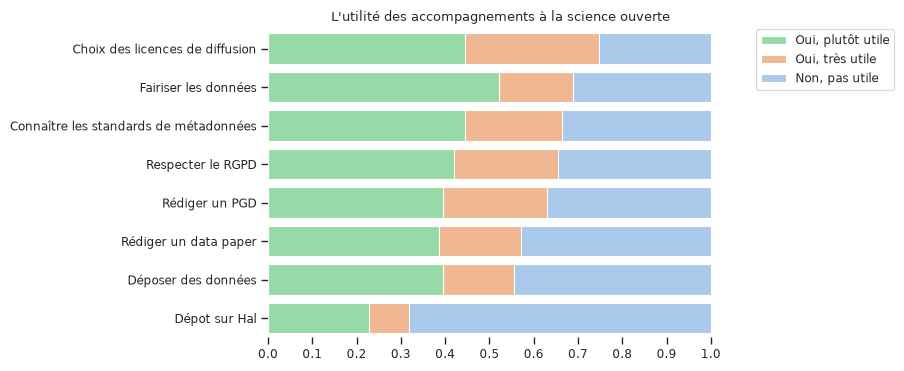

In [37]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(style="ticks", context="paper", palette="pastel")

   
g = sns.barplot(x="cum_sum", y="accomp_name", data=q8_ter, hue="interet_accomp", dodge=False)

titre = "L'utilité des accompagnements à la science ouverte"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0]

#add legend to plot


ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
sns.despine(left=True, bottom=True)
plt.savefig(f"viz/util_accomp_so.png", bbox_inches='tight', dpi = 200)

## Stockage, sauvegarde et archivage des données

Le stockage, la sauvegarde et l'archivage renvoient à des temps différents du cycle de la donnée. Le stockage correspond au moment où les données sont exploitées. Au contraire l'archivage intervient après la phase de traitement et d'analyse, dans un moment où les données ne sont plus manipulées. Enfin, la sauvegarde est une mesure visant à garantir la sécurité et l'integrité des données. Il est ainsi recommandé de copier ses données sur trois supports différents. Il est toutefois possible que les différences entre ces trois concepts ne soient pas connues de tous.

En termes de pratiques, en moyenne, les personnes interrogées sauvegardent leur données sur deux supports et en utilisent trois pour le stockage. La clé usb ou le disque dur externe sont les supports les plus utilisés que ce soit pour le stockage, la sauvegarde ou l'achivage. Concernant les clouds, ce sont les services commerciaux (Google, Icloud) qui arrivent en tête. 49% des répondants disent stocker ou sauvegarder leurs documents sur ces services et 42% les emploient comme espace d'achivage. À l'opposé, seulement 9% des personnes interrogées recourent au cloud de Paris 8 (5% si on parle de sauvegarde ou d'archivage).

```{figure} ./viz/pratiques_sauvegardes.png
:name: q33_save_data

Les lieux de stockage, de sauvegarde et d'archivage des données
```

In [38]:
df0[["q45_clé","q31_stockage_doc"]]

,q45_clé,q31_stockage_doc
0,PS8W-TJ9P,Sur papier;Sur votre ordinateur personnel;Sur ...
1,GNEG-5QXQ,Sur votre ordinateur pro;Sur un cloud commerci...
2,FCCB-GMYA,Sur votre ordinateur pro;Sur un cloud commerci...
3,CV3G-95CT,Sur votre ordinateur pro;Sur une clé USB ou un...
4,M5L8-UM9F,Sur papier;Sur votre ordinateur pro;Sur une cl...
...,...,...
114,MLSN-NBUS,Sur votre ordinateur pro;Sur une clé USB ou un...
115,WAR9-LFJP,Sur votre ordinateur personnel;Sur votre ordin...
116,HRZG-6JGE,Sur votre ordinateur pro;Sur une clé USB ou un...
117,32TW-JLY5,Sur papier;Sur votre ordinateur personnel;Sur ...


In [39]:
df_stock, gb_stock = split_multiple_choices(df0[["q45_clé","q31_stockage_doc"]], "q31_stockage_doc", "q45_clé", sep = '|')
gb_stock

,q31_stockage_doc,nb,total,freq,total_freq
0,Sur une clé USB ou un disque dur,80,119,67.226891,100.0
1,Sur votre ordinateur pro,78,119,65.546218,100.0
2,"Sur un cloud commercial : GoogleDrive, iCloud ...",58,119,48.739496,100.0
3,Sur votre ordinateur personnel,53,119,44.537815,100.0
4,Sur papier,49,119,41.176471,100.0
5,Sur le cloud d'un partenaire,15,119,12.605042,100.0
6,"Autre, précisez",14,119,11.764706,100.0
7,"Sur un cloud de Paris 8 : Nuxeo, Nextcloud",11,119,9.243697,100.0


In [40]:
nb_lieu = df_stock.groupby(["q45_clé"]).agg(nb=("q31_stockage_doc","size")).reset_index()
nb_lieu.groupby(["nb"]).agg(freq=("q45_clé","size"))
np.mean(nb_lieu.nb)
np.median(nb_lieu.nb)

np.float64(3.0)

In [41]:
df_save, gb_save = split_multiple_choices(df0[["q45_clé","q33_sauvegarde_data"]], "q33_sauvegarde_data", "q45_clé", sep = '|')
gb_save

,q33_sauvegarde_data,nb,total,freq,total_freq
0,Sur une clé usb ou sur un disque dur,79,119,66.386555,100.0
1,"Sur un cloud commercial : GoogleDrive, iCloud ...",58,119,48.739496,100.0
2,Sur ShareDocs ou équivalent,28,119,23.529412,100.0
3,Sur le cloud d'un partenaire,17,119,14.285714,100.0
4,"Sur GitHub, GitLab ou équivalent",15,119,12.605042,100.0
5,"Autre, précisez",10,119,8.403361,100.0
6,"Sur un cloud de Paris 8 : Nuxeo, NextCloud",7,119,5.882353,100.0
7,Je ne fais pas de sauvergarde,5,119,4.201681,100.0
8,Sur les espaces disques de Paris 8,5,119,4.201681,100.0


In [42]:
nb_lieu = df_save.groupby(["q45_clé"]).agg(nb=("q33_sauvegarde_data","size")).reset_index()
nb_lieu.groupby(["nb"]).agg(freq=("q45_clé","size"))
#np.mean(nb_lieu.nb)
#np.median(nb_lieu.nb)

,freq
nb,
1,46
2,48
3,20
4,3
5,2


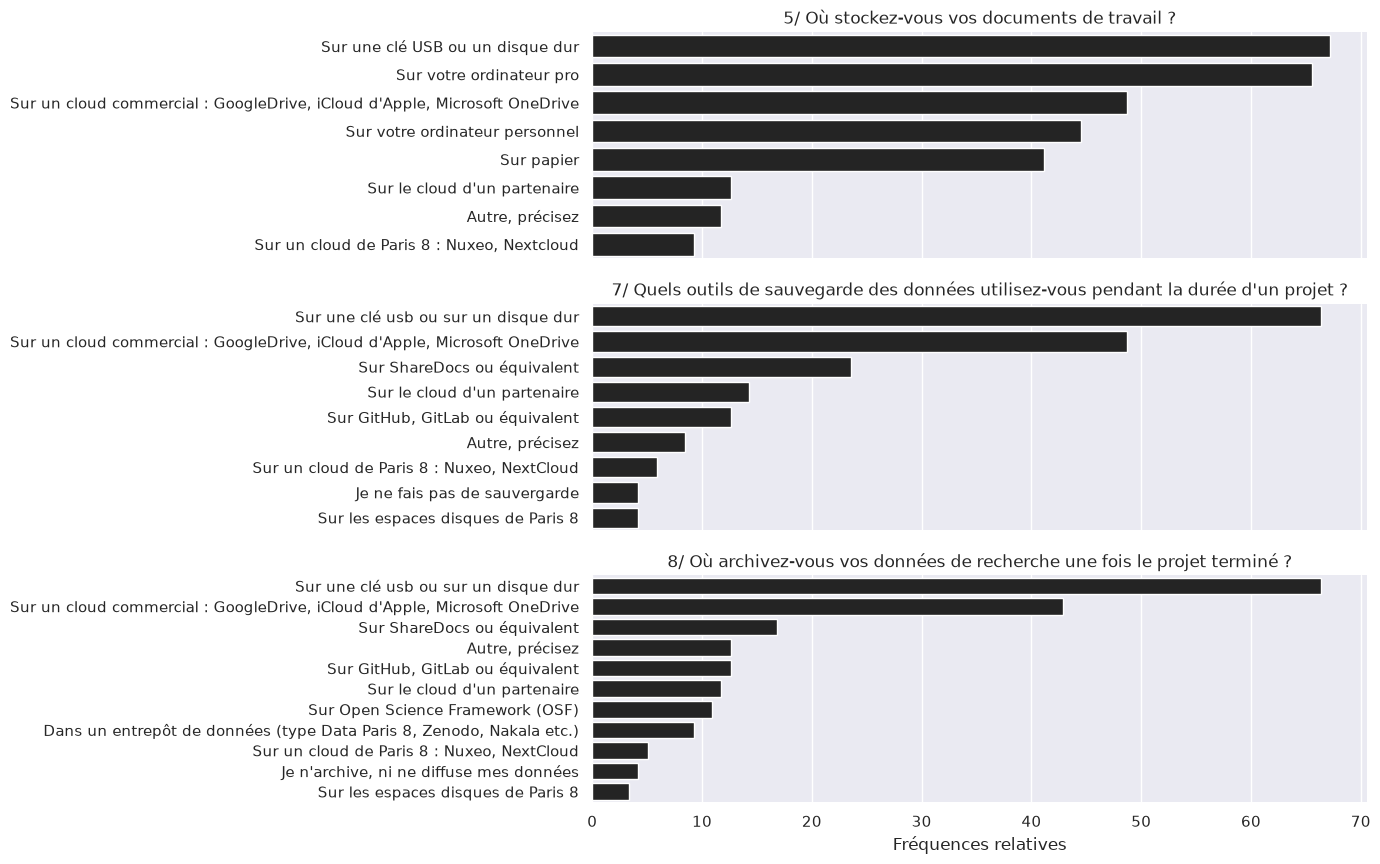

In [45]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(3,1, figsize=(10,10), sharex=True)

# Plot the total crashes
sns.set_theme(palette="gray")

i=-1
for col in ["q31_stockage_doc","q33_sauvegarde_data","q28_archive_data"]:
    i+=1
    question = [x for x in df_col.question.loc[df_col.label==col]]

    df_exp, gb_data = split_multiple_choices(df0[["q45_clé",col]], col, "q45_clé", sep = '|')

    sns.barplot(x="freq", y=col, data=gb_data,
                label="Oui",  ax=ax[i])
    titre = f"{question[0]}"
    ax[i].yaxis.set_label_text("")
    ax[i].xaxis.set_label_text("Fréquences relatives")
    ax[i].set_title(titre.replace("<i>","(").replace("</i>",")"))
    ax[i].legend_.remove()
        
    
    sns.despine(left=True, bottom=True)
plt.savefig(f"viz/pratiques_sauvegardes.png", bbox_inches='tight', dpi = 200)

In [46]:
df_exp, gb_archive = split_multiple_choices(df0, "q28_archive_data", "q45_clé", sep = '|')
gb_archive

,q28_archive_data,nb,total,freq,total_freq
0,Sur une clé usb ou sur un disque dur,79,119,66.386555,100.0
1,"Sur un cloud commercial : GoogleDrive, iCloud ...",51,119,42.857143,100.0
2,Sur ShareDocs ou équivalent,20,119,16.806723,100.0
3,"Autre, précisez",15,119,12.605042,100.0
4,"Sur GitHub, GitLab ou équivalent",15,119,12.605042,100.0
5,Sur le cloud d'un partenaire,14,119,11.764706,100.0
6,Sur Open Science Framework (OSF),13,119,10.924370,100.0
7,Dans un entrepôt de données (type Data Paris 8...,11,119,9.243697,100.0
8,"Sur un cloud de Paris 8 : Nuxeo, NextCloud",6,119,5.042017,100.0
9,"Je n'archive, ni ne diffuse mes données",5,119,4.201681,100.0


In [47]:
df0.q33_1_autre_suavegarde.unique()

array([nan, 'doc papiers', 'Cloud Propriétaire', 'protonDrive',
       'sdrive CNRS', 'Proton Drive', 'sur mon ordinateur portable',
       'serveurs persos', 'ordinateurs des collègues',
       'framadoc ou suite numérique', 'Je précise que le HDD est chiffré',
       'sur Backblaze (outil payant)', 'dropbox'], dtype=object)

In [48]:
df0.q31_1_autre_stockage.unique()

array([nan, 'Cloud Dropbox', 'Cloud Propriétaire', 'Sharedocs',
       'sdrive CNRS', 'share doc ', 'Proton Drive',
       'Sur des serveurs persos', "Sur le cloud d'Human-Num : Sharedocs",
       'suite numérique', 'Dropbox ',
       'travail hybride, donc cloud entreprise privée et cloud perso',
       'ShareDocs', 'Dropbox'], dtype=object)